In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/datasets/proakram/titanic/train.csv
/kaggle/input/datasets/proakram/titanic/test.csv
/kaggle/input/datasets/proakram/titanic/gender_submission.csv


# 🚢 Titanic Survival Prediction using Random Forest
### 🧑‍💻 Built by: Akram Al-Nafati

---

## 📌 Introduction / مقدمة المشروع
In this notebook, we build a robust predictive model using the **Random Forest Classifier** to predict the survival of passengers aboard the Titanic. We focus on rigorous data preprocessing, feature selection, and evaluating our model using a Confusion Matrix and a Detailed Classification Report.

في هذا المشروع، نقوم ببناء نموذج تنبؤي قوي باستخدام خوارزمية **الغابة العشوائية (Random Forest Classifier)** لتوقع نجاة ركاب سفينة تيتانيك. نركز في هذا الملف على التنظيف الدقيق للبيانات، واختيار الميزات المؤثرة، وتقييم النموذج عبر مصفوفة الارتباك وتقرير التصنيف التفصيلي.

## 1️⃣ Data Loading & Exploration | تحميل واستكشاف البيانات
First, we load the dataset into a Pandas DataFrame and inspect its structure using `.head()` and `.info()` to check for missing values and data types.

في هذه الخطوة، نقوم باستيراد البيانات واستكشاف هيكلها الإحصائي للتعرف على أنواع الأعمدة والمفقودات بداخلها.

In [2]:
import pandas as pd 
df = pd.read_csv("/kaggle/input/datasets/proakram/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 🔍 1. Identifying Missing Values | فحص واستكشاف القيم المفقودة

Before modifying our data, we calculate the total number of missing cells (`NaN`) in each column using `df.isnull().sum()`. This step helps us build an action plan for data imputation:
* **`Age`:** Has 177 missing entries (needs imputation).
* **`Cabin`:** Has 687 missing entries (too many missing values, best to drop).
* **`Embarked`:** Has only 2 missing entries (can be filled easily).

قبل البدء في تعديل البيانات، نقوم بحساب العدد الإجمالي للقيم المفقودة أو الفارغة في كل عمود باستخدام الدالة `df.isnull().sum()`. هذه الخطوة تمنحنا رؤية واضحة لوضع خطة المعالجة:
* **العمر (`Age`):** يحتوي على 177 قيمة مفقودة (يحتاج تعبئة).
* **الكابينة (`Cabin`):** يحتوي على 687 قيمة مفقودة (نسبة الفقد عالية جداً، الأفضل حذفه).
* **الميناء (`Embarked`):** يحتوي على قيمتين مفقودتين فقط (يمكن تعبئتهما بسهولة).
*

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 🛠️ 2. Data Imputation & Cleaning | معالجة وتنظيف القيم المفقودة

Now, we clean the dataset based on our inspection by applying three different strategies:
1. **Age:** We fill missing values with the **Median** to prevent outliers from affecting the model.
2. **Cabin:** We completely drop the column since more than 70% of its data is missing.
3. **Embarked:** We fill the 2 missing records using the **Mode** (the most frequent port).
Finally, we run `df.isnull().sum()` again to ensure that our dataset is 100% clean and free of any missing data.

الآن، نقوم بتنظيف الجدول بناءً على الفحص السابق عبر تطبيق ثلاث استراتيجيات مختلفة:
1. **العمر:** نقوم بتعبئة الفراغات باستخدام **الوسيط (Median)** لحماية النموذج من تأثير القيم الشاذة.
2. **الكابينة:** نقوم بحذف العمود بالكامل لأن نسبة الفراغات تتجاوز 70% من البيانات.
3. **الميناء:** نقوم بتعبئة القيمتين المفقودتين باستخدام **المنوال (Mode)** وهو الميناء الأكثر تكراراً في الرحلة.
في النهاية، نتحقق مجدداً بـ `df.isnull().sum()` للتأكد من أن البيانات أصبحت نظيفة تماماً وجاهزة لتعلم الآلة.

In [5]:
# 1. Age: fill with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Cabin: drop the column
df = df.drop(columns=['Cabin'])

# 3. Embarked: fill with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# تحقق من النتيجة
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 📊 3️⃣ Data Visualization | التحليل البصري للبيانات

To gain insights into the dataset, we visualize the relationship between the target variable (`Survived`) and key features. Here, we plot the **Survival Count by Gender** using `sns.countplot()`. 

This visualization highlights a critical pattern:
* **Males (Blue):** The vast majority did not survive.
* **Females (Orange):** The majority survived, showing that gender is a highly predictive feature for our model.

لفهم نمط البيانات بشكل أعمق، نقوم بتحليل العلاقة بصرياً بين عمود الهدف (`Survived`) والميزات الأساسية. هنا نقوم برسم **معدل النجاة حسب الجنس** باستخدام مكتبة `Seaborn`.

يظهر هذا الرسم البياني نمطاً جوهرياً وحاسماً:
* **الذكور (اللون الأزرق):** الغالبية العظمى منهم لم ينجوا.
* **الإناث (اللون البرتقالي):** النسبة الأكبر منهن نجون، مما يثبت أن عمود الجنس ميزة قوية ومؤثرة جداً سيعتمد عليها النموذج في التوقع.
*

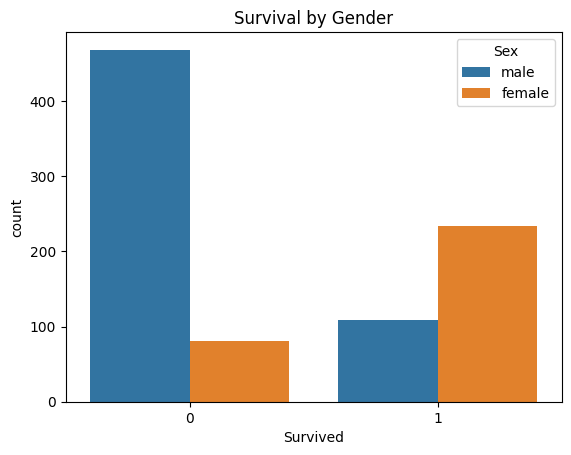

In [6]:
 import seaborn as sns
import matplotlib.pyplot as plt

# نسبة النجاة حسب الجنس
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.show()

### 📊 4️⃣ Data Visualization: Survival by Passenger Class | التحليل البصري: النجاة حسب درجة السفر

Next, we explore another critical factor: the passenger's socio-economic status, represented by their ticket class (`Pclass`). We use `sns.countplot()` with `hue='Pclass'` to analyze how the survival rate changes across classes (1 = First, 2 = Second, 3 = Third).

The chart reveals a stark reality:
* **Class 3 (Black):** The highest number of casualties occurred in the third class.
* **Class 1 (Light Gray):** Passengers in the first class had the highest chance of survival.
This confirms that `Pclass` is an essential feature that will heavily guide our Random Forest model during training.

في هذه الخطوة، نستكشف عاملاً حاسماً آخر وهو المستوى الاجتماعي والاقتصادي للركاب، والمتمثل في درجة تذكرة السفر (`Pclass`). نستخدم الرسم البياني التحليلي لمقارنة نسب النجاة والوفاة عبر الدرجات الثلاث (الدرجة الأولى، الثانية، والثالثة).

يكشف الرسم البياني عن واقع واضح جداً:
* **الدرجة الثالثة (اللون الأسود):** سجلت العدد الأكبر والأضخم من الوفيات (العمود 0).
* **الدرجة الأولى (اللون الرمادي الفاتح):** حظي ركابها بأعلى نسبة نجاة مقارنة بباقي الدرجات (العمود 1).
هذا يؤكد علمياً أن درجة السفر ميزة جوهرية ستلعب دوراً كبيراً في توجيه قرارات نموذج الغابة العشوائية أثناء التدريب.

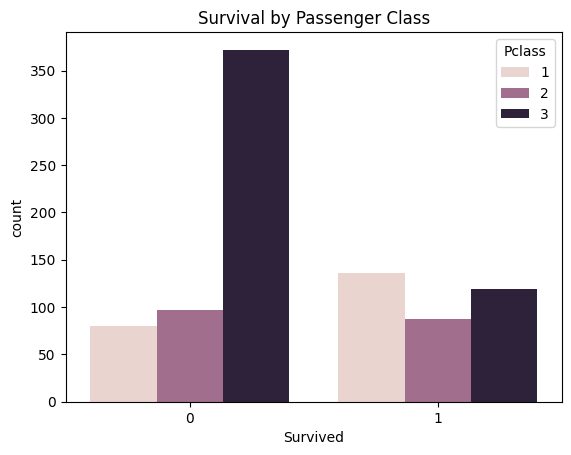

In [7]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')
plt.show()

## 🏷️ 5️⃣ Categorical Feature Encoding | التشفير الرقمي للميزات الفئوية

Since machine learning algorithms operate on mathematical principles, they cannot process textual descriptions directly (such as "male"/"female" or ports "C", "Q", "S"). To handle this, we use the **`LabelEncoder`** utility from Scikit-Learn to map these categorical categories into distinct numerical scales.

In this block, we apply the encoding sequentially:
1. **`Sex` Column:** Converts string values into a binary representation (`0` and `1`).
2. **`Embarked` Column:** Encodes the travel ports into unique integer labels (`0`, `1`, and `2`).
Finally, we execute `.head()` to verify that our structural transformation has been applied successfully across the columns.

بما أن خوارزميات تعلم الآلة تعتمد بالكامل على المعادلات الرياضية، فهي لا تستطيع فهم النصوص البرمجية مباشرة (مثل الكلمات النصية للجنس وموانئ السفر). لمعالجة هذه المشكلة، نقوم باستدعاء أداة **`LabelEncoder`** لتحويل الفئات النصية إلى قيم رقمية متسلسلة.

في هذه الخلية، نقوم بتطبيق الترميز بالتوالي:
1. **عمود الجنس (`Sex`):** يتم تحويل الكلمات النصية إلى تمثيل ثنائي رقمي (`0` و `1`).
2. **عمود الميناء (`Embarked`):** يتم تشفير الموانئ المختلفة إلى أرقام صحيحة فريدة (`0` و `1` و `2`).
في النهاية، نستدعي دالة المعاينة `.head()` للتأكد من نجاح هيكلة الجدول وتحويل الأعمدة المحددة بنجاح.

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

df[['Sex', 'Embarked']].head()

,Sex,Embarked
0,1,2
1,0,0
2,0,2
3,0,2
4,1,2


## 🎯 6️⃣ Feature Selection & Target Isolation | اختيار الميزات وعزل الهدف

Now that our data is fully imputed, cleaned, and encoded, we split the dataset into two structural components:
1. **`X` (Feature Matrix):** Contains the selected predictive columns (`Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`) that serve as input signals for our model. We exclude non-informative identifiers like `PassengerId`, `Name`, and `Ticket`.
2. **`y` (Target Vector):** Holds the actual labels we intend to predict (`Survived`).

We then call `.shape` to confirm that the dimensions of both structures match correctly before proceeding to data splitting.

الآن بعد أن أصبحت بياناتنا جاهزة، ونظيفة، ومفرزة رقمياً بالكامل، نقوم بفصل الجدول إلى مكونين أساسيين:
1. **مصفوفة الميزات (`X`):** وتضم الأعمدة السبعة المحددة والتي تحمل الإشارات القوية المؤثرة على مصير الركاب. لقد استبعدنا يدوياً الأعمدة غير المفيدة رياضياً مثل رقم الراكب، الاسم، ورقم التذكرة.
2. **متغير الهدف (`y`):** ويحتوي حصراً على العمود المراد توقعه وكشف سرّه وهو (`Survived`).

في النهاية، نستدعي خاصية `.shape` للتأكد برمجياً من تطابق عدد الأسطر (891 راكباً) في كلا المتغيرين لضمان سلامة الخطوات القادمة.

In [9]:
# الأعمدة التي سندخلها للموديل
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# العمود الذي نريد التنبؤ به
y = df['Survived']

print(X.shape)
print(y.shape)

(891, 7)
(891,)


## ✂️ 7️⃣ Data Splitting: Training & Testing Sets | تقسيم البيانات إلى مجموعات التدريب والاختبار

To evaluate the true generalization capability of our machine learning model, we must test it on unseen data. We use the **`train_test_split`** function from Scikit-Learn to partition our features (`X`) and target labels (`y`) into two distinct subsets:
* **Training Set (80%):** Comprising 712 samples used to fit and train the Random Forest weights.
* **Testing Set (20%):** Comprising 179 samples reserved strictly for validation and final metric evaluation.

We explicitly pass `random_state=42` to secure an identical data shuffle and split across multiple executions, making our research stable and reproducible.

لتقييم مدى قدرة نموذج تعلم الآلة على التعميم وتوقع النتائج بدقة، يجب أن نختبره على بيانات لم يسبق له رؤيتها أثناء التدريب. نستخدم دالة **`train_test_split`** لتقسيم مصفوفة الميزات (`X`) ومتغير الهدف (`y`) إلى مجموعتين منفصلتين:
* **مجموعة التدريب (80%):** وتتكون من 712 راكباً، وتُستخدم لتدريب وبناء أشجار القرار داخل الغابة العشوائية.
* **مجموعة الاختبار (20%):** وتتكون من 179 راكباً، وتُحفظ جانباً لتقييم الدقة النهائية للنموذج.

نقوم بتمرير المعامل `random_state=42` لضمان الحصول على نفس تقسيم البيانات العشوائي تماماً في كل مرة نُعيد فيها تشغيل الكود، مما يضمن ثبات واستقرار تجاربنا التقنية.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


## 🌲 8️⃣ Model Training & Comprehensive Evaluation | تدريب وتقييم نموذج الغابة العشوائية

With our data properly split, we instantiate and train the **`RandomForestClassifier`** using 100 decision trees (`n_estimators=100`) and fix `random_state=42` for consistent behavior. After fitting the model on the training data, we evaluate its performance using three powerful metrics:
1. **Overall Accuracy:** Measures the percentage of correctly predicted passengers.
2. **Confusion Matrix:** Breaks down the exact counts of True Negatives (92), False Positives (13), False Negatives (19), and True Positives (55).
3. **Classification Report:** Provides deeper statistical insight by calculating **Precision**, **Recall**, and **F1-Score** for both classes (0: Deceased, 1: Survived).

Our configuration yields a solid test accuracy of **82.12%**, proving the model is stable and generalized well.

بعد تقسيم البيانات بنجاح، نقوم الآن بإنشاء وتدريب نموذج **`RandomForestClassifier`** المكون من 100 شجرة قرار ذكية، مع تثبيت `random_state=42` لضمان استقرار النتائج. بعد إتمام التدريب، نقوم بتقييم كفاءة الغابة العشوائية عبر ثلاثة مقاييس معيارية:
1. **الدقة الإجمالية (Accuracy):** وتقيس النسبة العامة للإجابات الصحيحة للنموذج.
2. **مصفوفة الارتباك (Confusion Matrix):** وتوضح التوزيع الدقيق للتوقعات الصائبة والخاطئة؛ حيث أصاب النموذج في تنبؤ (92) حالة وفاة و (55) حالة نجاة بشكل صحيح تماماً.
3. **تقرير التصنيف التفصيلي (Classification Report):** ويمنحنا تحليلاً أعمق للأداء عبر حساب قيم **الدقة (Precision)** و**الاستدعاء (Recall)** ومقياس **F1-Score** لكل فئة على حدة (0 للوفاة، و 1 للنجاة).

أظهرت الغابة العشوائية أداءً قوياً ومستقراً للغاية، حيث حققت دقة نهائية بلغت **82.12%** على بيانات الاختبار الجديدة.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully!")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nCofusin Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))

Model trained successfully!
Model Accuracy: 82.12%

Cofusin Matrix:
[[92 13]
 [19 55]]

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 🏁 Conclusion & Key Takeaways | الخاتمة وأهم الاستنتاجات

We have successfully completed our end-to-end Machine Learning pipeline using the **Random Forest Classifier** to predict Titanic passenger survival. 

### 💡 Key Findings:
* **Model Performance:** Our model achieved a strong and stable accuracy of **82.12%** on the unseen test data.
* **Feature Importance:** Data exploration and model behavior confirmed that **Gender (`Sex`)** and **Socio-economic Status (`Pclass`)** were the most critical driving factors in predicting survival.
* **Robustness:** Fixing the random state (`42`) ensured that our results are fully reproducible and valid for further enhancements.

### 🚀 Next Steps:
1. Feature engineering to extract titles (e.g., Mr, Mrs, Miss) from the `Name` column.
2. Hyperparameter tuning using `GridSearchCV` to optimize the Random Forest trees further.
3. Applying the final trained model to the `test.csv` file for official Kaggle submission.

---

لقد قمنا بنجاح بإتمام دورة بناء نموذج تعلم الآلة بالكامل من البداية وحتى التقييم باستخدام خوارزمية **الغابة العشوائية (Random Forest Classifier)** لتوقع نجاة ركاب تيتانيك.

### 💡 أهم الاستنتاجات:
* **أداء النموذج:** حقق النموذج دقة قوية ومستقرة بلغت **82.12%** على بيانات الاختبار التي لم يرها من قبل.
* **أهمية الميزات:** أكد التحليل البصري وسلوك الخوارزمية أن **الجنس (`Sex`)** و**الدرجة الاجتماعية والاقتصادية (`Pclass`)** هما العاملان الأكثر حسمًا وتأثيرًا في تحديد فرص النجاة.
* **الموثوقية:** تضمن عملية تثبيت العشوائية (`42`) إمكانية تكرار هذه النتائج بدقة ومقارنتها بأي تحسينات مستقبلية.

### 🚀 الخطوات القادمة:
1. استخراج الألقاب (مثل Mr, Mrs, Miss) من عمود الأسماء كميزات إضافية لدعم النموذج.
2. ضبط المعاملات الفائقة (Hyperparameter Tuning) باستخدام `GridSearchCV` لرفع كفاءة أشجار الغابة العشوائية.
3. تطبيق النموذج المدرب نهائيًا على ملف `test.csv` لتجهيز ملف المخرجات ورفعه على منصة كاجل.
